# 09 JUNE 2026

In [2]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
                                        train_test_split,
                                        StratifiedKFold,
                                        cross_validate,
                                        RandomizedSearchCV,
                                        cross_val_score
                                    )
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
                                RandomForestClassifier,
                                GradientBoostingClassifier,
                                StackingClassifier
                            )
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ( accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,
                             roc_curve,confusion_matrix,classification_report,ConfusionMatrixDisplay)
from sklearn.base import BaseEstimator, TransformerMixin

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Cleaning & Feature Engineering

In [3]:
# ******* Load Data *********
df = pd.read_csv(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\bank-full.csv", sep=';')

df.drop('duration', axis=1, inplace=True)

# ******* Target encoding *********
df['y'] = df['y'].map({'no':0,'yes':1})

# ******* FEATURE ENGINNERING *********
def create_features(df):
    df = df.copy()
    df['contacted_before'] = np.where(df['previous'] > 0,1,0)
    df['total_loans'] = (
                            (df['housing'] == 'yes').astype(int)+
                            (df['loan'] == 'yes').astype(int)
                        )
    df['age_balance'] = (df['age']*df['balance'])
    return df

# ******* FEATURES & TARGET VARIABLE SEPARATION *********
X = df.drop('y', axis=1)
y = df['y']

X = create_features(X)

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               45211 non-null  int64 
 1   job               45211 non-null  object
 2   marital           45211 non-null  object
 3   education         45211 non-null  object
 4   default           45211 non-null  object
 5   balance           45211 non-null  int64 
 6   housing           45211 non-null  object
 7   loan              45211 non-null  object
 8   contact           45211 non-null  object
 9   day               45211 non-null  int64 
 10  month             45211 non-null  object
 11  campaign          45211 non-null  int64 
 12  pdays             45211 non-null  int64 
 13  previous          45211 non-null  int64 
 14  poutcome          45211 non-null  object
 15  contacted_before  45211 non-null  int64 
 16  total_loans       45211 non-null  int64 
 17  age_balance 

# Preprocessing

In [4]:
# ******* FEATURES Details *********
numeric_features = ['age','balance','day','campaign','pdays','previous','age_balance','total_loans','contacted_before']
ordinal_features = ['education']
categorical_features = ['job','marital','default','housing','loan','contact','month','poutcome']

numeric_transformer = Pipeline([
                                    ('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', RobustScaler())
                                ])

ordinal_transformer = Pipeline([
                                    ('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('ordinal', OrdinalEncoder(categories=[['unknown','primary','secondary','tertiary']]))
                                ])

categorical_transformer = Pipeline([
                                        ('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('onehot', OneHotEncoder(handle_unknown='ignore'))
                                    ])

preprocessor = ColumnTransformer([
                                    ('num',numeric_transformer,numeric_features),
                                    ('ord',ordinal_transformer,ordinal_features),
                                    ('cat',categorical_transformer,categorical_features)
                                ])

In [5]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

# Train Test Split

In [23]:
# ******* Train-test Split *********
X_train,X_test,y_train,y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

# Binary Classification Model

In [24]:
models = [
            LogisticRegression(solver='liblinear',max_iter=5000,random_state=42),
            RandomForestClassifier(n_estimators=100,random_state=42),
            GradientBoostingClassifier(random_state=42),
            XGBClassifier(eval_metric='logloss',random_state=42),
            LGBMClassifier(random_state=42),
            CatBoostClassifier(verbose=0,random_state=42),
            GaussianNB(),
            #SVC(probability=True,random_state=42)
          ]
results = []

for model in models:
    model_pipeline = Pipeline([
                        ('preprocessor', preprocessor),
                        ('smote', SMOTE(random_state=42)),
                        ('model', model)
                    ])

    model_pipeline.fit(X_train,y_train)

    preds = model_pipeline.predict(X_test)
    probs = model_pipeline.predict_proba(X_test)[:,1]

    print(type(model).__name__)
    results.append({'Model': type(model).__name__, 
                    'Accuracy' : accuracy_score(y_test, preds), 
                    'Precision' : precision_score(y_test, preds), 
                    'Recall' : recall_score(y_test, preds), 
                    'F1' : f1_score(y_test, preds), 
                    'ROC_AUC' : roc_auc_score(y_test, probs)})
    
result_df = pd.DataFrame(results)
print(result_df.sort_values(by='ROC_AUC',ascending=False))

LogisticRegression
RandomForestClassifier
GradientBoostingClassifier
XGBClassifier
[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11836
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier
CatBoostClassifier
GaussianNB
                        Model  Accuracy  Precision    Recall        F1  \
5          CatBoostClassifier  0.893177   0.591633  0.280718  0.380769   
3               XGBClassifier  0.891629   0.577381  0.275047  0.372599   
4              LGBMClassifier  0.893398   0.586397  0.301512  0.398252   
2  GradientBoostingClassifier  0.883556   0.503090  0.384688  0.435994   
1      RandomForestClassifier  0.888201   0.538843  0.308129  0.392063   
0          LogisticRegression  0.752958   0.263475  0.619093  0.369639   
6                  GaussianNB  0.762358   0.268168  0.596408  0.369979   

    ROC_AUC  
5  0.796204  
3  0.791330  
4  0.790301  
2  0.780390  
1  0.780306  
0  0.766135  
6  0.743862  


In [25]:
result_df.to_csv(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\Metrics_Comparision.csv")

In [26]:
result_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.752958,0.263475,0.619093,0.369639,0.766135
1,RandomForestClassifier,0.888201,0.538843,0.308129,0.392063,0.780306
2,GradientBoostingClassifier,0.883556,0.503090,0.384688,0.435994,0.780390
3,XGBClassifier,0.891629,0.577381,0.275047,0.372599,0.791330
4,LGBMClassifier,0.893398,0.586397,0.301512,0.398252,0.790301
5,CatBoostClassifier,0.893177,0.591633,0.280718,0.380769,0.796204
6,GaussianNB,0.762358,0.268168,0.596408,0.369979,0.743862


# HyperParameter Tuning

In [35]:
lgbm_pipe = Pipeline([
                        ('preprocessor', preprocessor),
                        ('smote', SMOTE(random_state=42)),
                        ('model', LGBMClassifier(random_state=42))
                    ])


params = {
            'model__num_leaves': [31, 50, 70, 100],
            'model__max_depth': [-1, 5, 10, 15],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__n_estimators': [100, 200, 500],
            'model__subsample': [0.8, 0.9, 1.0],
            'model__colsample_bytree': [0.8, 0.9, 1.0]
        }

search = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=params,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("\nBest ROC-AUC:")
print(search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11836
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Parameters:
{'model__subsample': 0.8, 'model__num_leaves': 70, 'model__n_estimators': 500, 'model__max_depth': -1, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}

Best ROC-AUC:
0.7881065320565703


In [44]:
# Get the model and evaluate of Test data
best_lgbm = search.best_estimator_

y_pred = best_lgbm.predict(X_test)
y_prob = best_lgbm.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.35).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8908548048214088
Precision: 0.5439900867410161
Recall   : 0.41493383742911155
F1 Score : 0.4707774798927614
ROC-AUC  : 0.7948950832906218


In [47]:
joblib.dump(best_lgbm, r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\lgbm_pipeline.pkl")
print("Model saved successfully!")

Model saved successfully!


In [37]:
xgb_pipe = Pipeline([
                        ('preprocessor', preprocessor),
                        ('smote', SMOTE(random_state=42)),
                        ('model', XGBClassifier(eval_metric='logloss',random_state=42))
                    ])

params = {
            'model__n_estimators': [100, 200, 300, 500],
            'model__max_depth': [3, 5, 7, 10],
            'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'model__subsample': [0.7, 0.8, 0.9, 1.0],
            'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            'model__gamma': [0, 0.1, 0.2, 0.3],
            'model__min_child_weight': [1, 3, 5, 7]
        }

search = RandomizedSearchCV(
                                estimator=xgb_pipe,
                                param_distributions=params,
                                n_iter=30,
                                scoring='roc_auc',
                                cv=5,
                                n_jobs=-1,
                                random_state=42,
                                verbose=1
                            )

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}

Best CV ROC-AUC:
0.7842031601001731


In [43]:
best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8933982085591065
Precision: 0.5959183673469388
Recall   : 0.27599243856332706
F1 Score : 0.3772609819121447
ROC-AUC  : 0.7948950832906218


In [52]:
joblib.dump(best_xgb, r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\xgb_pipeline.pkl")
print("Model saved successfully!")

Model saved successfully!


In [39]:
cat_pipe = Pipeline([
                        ('preprocessor', preprocessor),
                        ('smote', SMOTE(random_state=42)),
                        ('model', CatBoostClassifier(random_state=42,verbose=0))
                    ])

params = {
            'model__iterations': [100, 200, 500, 1000],
            'model__depth': [4, 6, 8, 10],
            'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'model__l2_leaf_reg': [1, 3, 5, 7, 9],
            'model__border_count': [32, 64, 128, 254]
        }

search = RandomizedSearchCV(
                                estimator=cat_pipe,
                                param_distributions=params,
                                n_iter=30,
                                scoring='roc_auc',
                                cv=5,
                                n_jobs=-1,
                                random_state=42,
                                verbose=1,
                                error_score='raise'
                            )

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 3, 'model__iterations': 1000, 'model__depth': 4, 'model__border_count': 128}

Best CV ROC-AUC:
0.7922967249737584


In [45]:
best_cat = search.best_estimator_

y_pred = best_cat.predict(X_test)
y_prob = best_cat.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.35).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8908548048214088
Precision: 0.5439900867410161
Recall   : 0.41493383742911155
F1 Score : 0.4707774798927614
ROC-AUC  : 0.7948950832906218


In [46]:
joblib.dump(best_cat, r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Data\catboost_pipeline.pkl")
print("Model saved successfully!")

Model saved successfully!


In [86]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

# ROC Curve Visualization

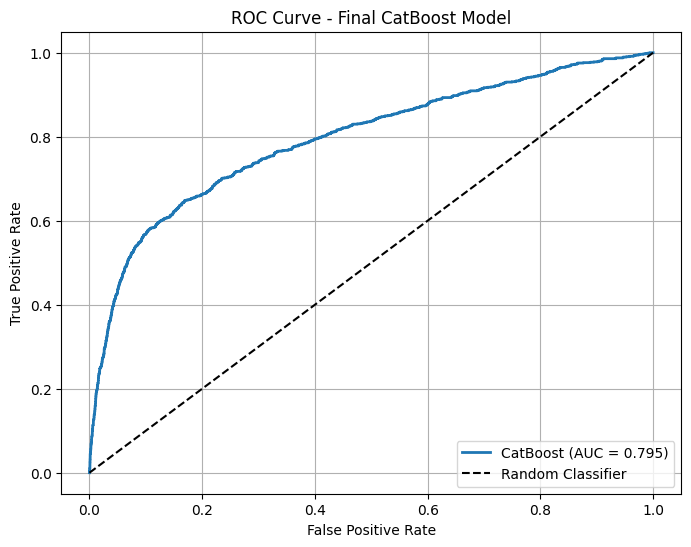

In [49]:
# Predicted probabilities
y_prob = best_cat.predict_proba(X_test)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'CatBoost (AUC = {roc_auc:.3f})'
)

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final CatBoost Model')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

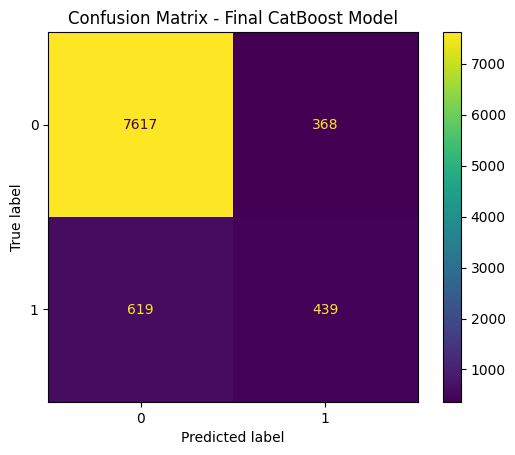

In [51]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.title("Confusion Matrix - Final CatBoost Model")
plt.show()

# Stacking

In [56]:
lgbm_model = LGBMClassifier(
                                subsample=0.8,
                                num_leaves=70,
                                n_estimators=500,
                                max_depth=-1,
                                learning_rate=0.01,
                                colsample_bytree=0.9,
                                random_state=42
                            )

xgb_model = XGBClassifier(
                            subsample=0.8,
                            n_estimators=200,
                            min_child_weight=3,
                            max_depth=7,
                            learning_rate=0.1,
                            gamma=0.1,
                            colsample_bytree=0.7,
                            eval_metric='logloss',
                            random_state=42
                        )

cat_model = CatBoostClassifier(
                                learning_rate=0.1,
                                l2_leaf_reg=3,
                                iterations=1000,
                                depth=4,
                                border_count=128,
                                verbose=0,
                                random_state=42
                            )

stack_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
        StackingClassifier(
            estimators=[
                ('cat', cat_model),
                ('lgbm', lgbm_model),
                ('xgb', xgb_model)
            ],
            final_estimator=LogisticRegression(),
            cv=5,
            n_jobs=-1
        )
    )
])

stack_model.fit(X_train, y_train)

y_pred = stack_model.predict(X_test)
y_prob = stack_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >=  0.35).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.8960521950680084
Precision: 0.5899390243902439
Recall   : 0.3657844990548204
F1 Score : 0.4515752625437573
ROC-AUC  : 0.8097473642095943


# Blending

In [ ]:
cat_prob = best_cat.predict_proba(X_test)[:,1]
lgbm_prob = best_lgbm.predict_proba(X_test)[:,1]
xgb_prob = best_xgb.predict_proba(X_test)[:,1]

blend_prob = (
    0.5 * cat_prob +
    0.3 * lgbm_prob +
    0.2 * xgb_prob
)

y_pred = (blend_prob >= 0.35).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8908548048214088
Precision: 0.5439900867410161
Recall   : 0.41493383742911155
F1 Score : 0.4707774798927614
ROC-AUC  : 0.8097473642095943


# Stratified K-Fold cross-validation

In [64]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cat_pipe = Pipeline([
                        ('preprocessor', preprocessor),
                        ('smote', SMOTE(random_state=42)),
                        ('model', CatBoostClassifier(random_state=42,verbose=0))
                    ])
params = {
            'model__iterations': [200, 500, 1000],
            'model__depth': [4, 6, 8],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__l2_leaf_reg': [3, 5, 7, 9],
            'model__border_count': [64, 128, 254]
        }

search = RandomizedSearchCV(
                                estimator=cat_pipe,
                                param_distributions=params,
                                n_iter=30,
                                scoring='roc_auc',
                                cv=skf,
                                n_jobs=-1,
                                random_state=42,
                                verbose=1
                            )

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("\nBest ROC-AUC:")
print(search.best_score_)

best_cat = search.best_estimator_

y_pred = best_cat.predict(X_test)
y_prob = best_cat.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

scores = cross_val_score(
    cat_pipe,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print("ROC-AUC Scores:", scores)
print("Mean ROC-AUC :", scores.mean())
print("Std ROC-AUC  :", scores.std())

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'model__learning_rate': 0.05, 'model__l2_leaf_reg': 3, 'model__iterations': 500, 'model__depth': 6, 'model__border_count': 128}

Best ROC-AUC:
0.7927795706078843
Accuracy : 0.8942828707287405
Precision: 0.6032388663967612
Recall   : 0.28166351606805295
F1 Score : 0.38402061855670105
ROC-AUC  : 0.7989247324555848
ROC-AUC Scores: [0.78555185 0.79732795 0.78750151 0.78439305 0.79712281]
Mean ROC-AUC : 0.7903794354575584
Std ROC-AUC  : 0.005677673254388262


# Feature Importance

In [67]:
cat_model = best_cat.named_steps['model']
feature_names = best_cat.named_steps['preprocessor'].get_feature_names_out()

importance_cat = pd.DataFrame({
                                    'Feature': feature_names,
                                    'Importance': cat_model.feature_importances_
                                })

importance_cat = importance_cat.sort_values(
                                                by='Importance',
                                                ascending=False
                                            )

print(importance_cat.head(10))

                 Feature  Importance
3          num__campaign   24.643073
2               num__day   12.668580
9         ord__education    9.261438
0               num__age    8.819836
23  cat__marital_married    4.902553
19   cat__job_technician    3.481367
11  cat__job_blue-collar    2.743090
14   cat__job_management    2.681135
42        cat__month_may    2.462123
39        cat__month_jul    2.397488


In [68]:
importance_cat.to_csv(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Model\feature_importance.csv",index=False)

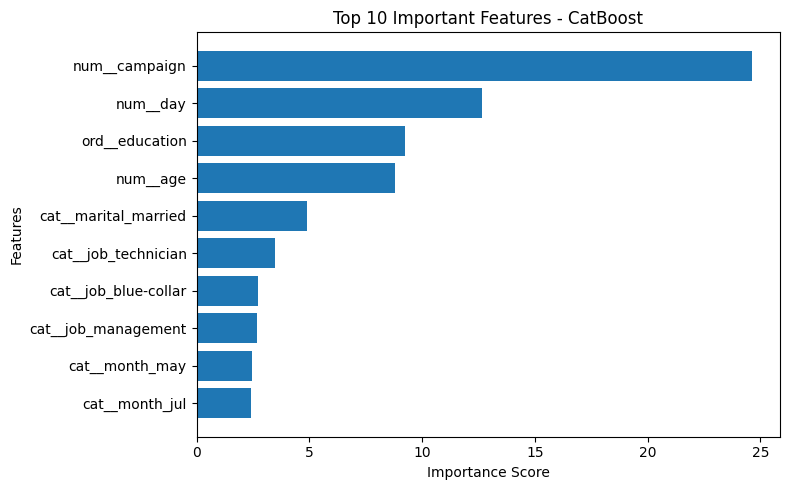

In [73]:
top_features = importance_cat.head(10)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - CatBoost")
plt.tight_layout()
plt.show()

# SHAP for model explainability

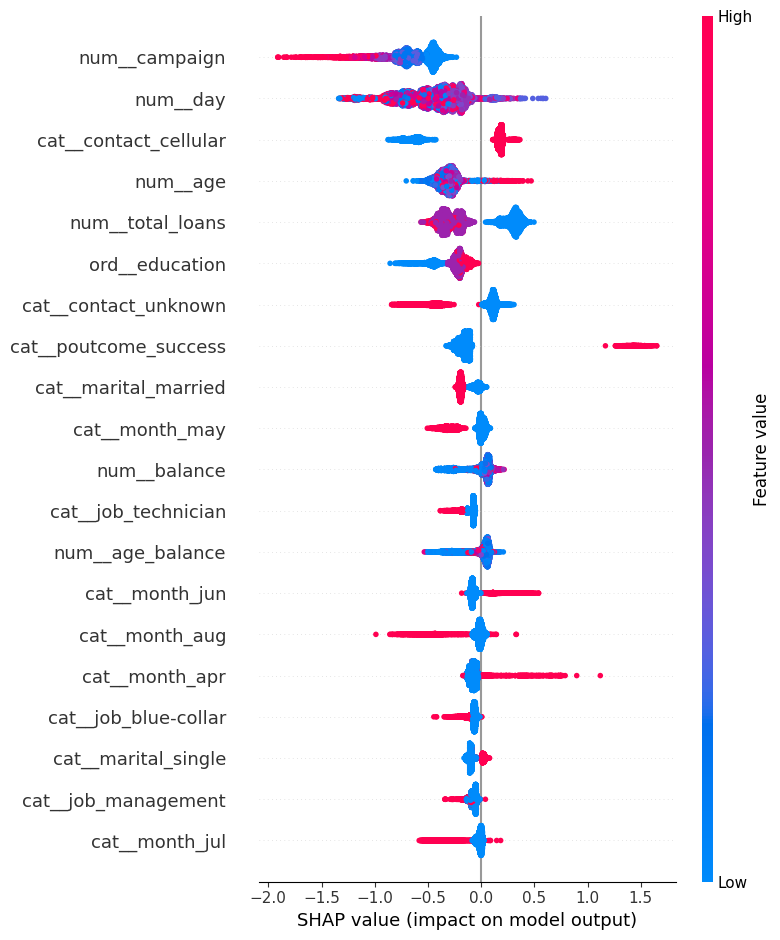

In [76]:
cat_model = best_cat.named_steps['model']
preprocessor = best_cat.named_steps['preprocessor']

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

# Prediction

In [88]:
model = joblib.load(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Model\catboost_pipeline.pkl")
feature_columns = joblib.load(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Model\feature_columns.pkl")

def create_features(df):
    df = df.copy()
    df['contacted_before'] = np.where(df['previous'] > 0,1,0)
    df['total_loans'] = (
                            (df['housing'] == 'yes').astype(int)+
                            (df['loan'] == 'yes').astype(int)
                        )
    df['age_balance'] = (df['age']*df['balance'])
    return df

new_customer = pd.DataFrame({
    'age': [35],
    'job': ['admin.'],
    'marital': ['married'],
    'education': ['secondary'],
    'default': ['no'],
    'balance': [2000],
    'housing': ['yes'],
    'loan': ['no'],
    'contact': ['cellular'],
    'day': [15],
    'month': ['may'],
    'duration': [300],
    'campaign': [2],
    'pdays': [999],
    'previous': [0],
    'poutcome': ['unknown']
})

customer_df = create_features(new_customer)

# Predict
prediction = model.predict(customer_df)[0]
probability = model.predict_proba(customer_df)[0]

print("Prediction:", prediction)
print(f"No Subscription Probability: {probability[0]:.2%}")
print(f"Subscription Probability: {probability[1]:.2%}")

if prediction == 1:
    print("Customer is likely to subscribe.")
else:
    print("Customer is unlikely to subscribe.")

Prediction: 0
No Subscription Probability: 75.73%
Subscription Probability: 24.27%
Customer is unlikely to subscribe.


In [90]:
model = joblib.load(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Model\catboost_pipeline.pkl")
feature_columns = joblib.load(r"C:\Users\nisha\OneDrive\Desktop\Nisha\GUVI\FinalProject\BankTermDepositPrediction\Model\feature_columns.pkl")

def create_features(df):
    df = df.copy()
    df['contacted_before'] = np.where(df['previous'] > 0,1,0)
    df['total_loans'] = (
                            (df['housing'] == 'yes').astype(int)+
                            (df['loan'] == 'yes').astype(int)
                        )
    df['age_balance'] = (df['age']*df['balance'])
    return df

new_customer = pd.DataFrame({
    'age': [20],
    'job': ['student.'],
    'marital': ['single'],
    'education': ['secondary'],
    'default': ['no'],
    'balance': [502],
    'housing': ['no'],
    'loan': ['no'],
    'contact': ['cellular'],
    'day': [30],
    'month': ['may'],
    'duration': [261],
    'campaign': [1],
    'pdays': [-1],
    'previous': [0],
    'poutcome': ['unknown']
})

customer_df = create_features(new_customer)

# Predict
prediction = model.predict(customer_df)[0]
probability = model.predict_proba(customer_df)[0]

print("Prediction:", prediction)
print(f"No Subscription Probability: {probability[0]:.2%}")
print(f"Subscription Probability: {probability[1]:.2%}")

if prediction == 1:
    print("Customer is likely to subscribe.")
else:
    print("Customer is unlikely to subscribe.")

Prediction: 1
No Subscription Probability: 43.61%
Subscription Probability: 56.39%
Customer is likely to subscribe.
